# Energy Demand Forecasting using ARIMA/SARIMA and Power BI

**Project:** End-to-end electricity demand forecasting pipeline -- data cleaning, EDA, feature
engineering, stationarity testing, ARIMA/SARIMA modeling, evaluation, and business insights,
feeding an interactive Power BI dashboard.

**Dataset:** 3 years (2022-2024) of hourly electricity demand, solar generation, wind generation,
and temperature data. See `README.md` for a note on data provenance.

This notebook mirrors `main.py` step-by-step with explanations. Run the modules from `src/` or
run `python main.py` from the project root to regenerate all outputs from scratch.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
import pandas as pd
import numpy as np

from preprocessing import run_preprocessing_pipeline
from feature_engineering import run_feature_engineering
from eda import run_full_eda
from forecasting import (adf_test, kpss_test, compute_acf_pacf, decompose_series,
                          fit_arima, fit_sarima, forecast_model, STATSMODELS_AVAILABLE)
from evaluation import evaluate_forecast, compare_models
import visualization as viz

print("statsmodels available:", STATSMODELS_AVAILABLE)


statsmodels available: False


## Step 1 -- Data Cleaning

**Decisions made (see `src/preprocessing.py` docstrings for full rationale):**
- Timestamps parsed and set as index; a complete hourly `DatetimeIndex` is reindexed onto the
  data so missing hours become explicit NaN rows rather than silent gaps.
- Duplicate timestamps dropped (keep first).
- Missing values filled with **time-based interpolation**, not mean/median -- demand and
  temperature are strongly autocorrelated hour-to-hour, so neighbouring values are far better
  estimates than a flat column average.
- Outliers **capped (winsorized)** via IQR (factor=3.0, wider than the classic 1.5 since demand
  data has legitimate sharp peaks) rather than dropped, to preserve the continuous hourly index
  ARIMA/SARIMA require.
- Physically impossible negative generation values corrected via absolute value (sign-entry errors).


In [1]:
df = run_preprocessing_pipeline(
    raw_path="../data/raw/energy_demand_raw.csv",
    processed_path="../data/processed/cleaned_data.csv",
)
df.head()

[preprocessing] Loaded 26344 raw rows.
[preprocessing] Removed 40 duplicate rows.
[preprocessing] Corrected 5 negative values in solar_gen_mw (sign errors).
[preprocessing] Filled missing values via time interpolation (657 -> 0 remaining NaNs).
[preprocessing] Capped 21 outliers in demand_mw (bounds: -598.4 to 7240.5).
[preprocessing] Capped 536 outliers in solar_gen_mw (bounds: -450.0 to 600.0).
[preprocessing] Capped 20 outliers in wind_gen_mw (bounds: -420.2 to 842.2).
[preprocessing] Cleaned dataset saved (26304 rows, 2022-01-01 00:00:00 to 2024-12-31 23:00:00).


## Step 3 -- Feature Engineering

Calendar features (year/month/week/day/hour/quarter/weekend), lag features (1h, 24h, 168h),
rolling mean/std (24h, 168h windows), and a differenced series are added here -- ahead of EDA
in this notebook because the EDA charts below (weekday/weekend split, hourly pattern, etc.)
rely on these columns. See `src/feature_engineering.py` for the reasoning behind each feature.


In [1]:
df = run_feature_engineering(df)
df[["demand_mw","hour","is_weekend","demand_mw_lag_24","demand_mw_roll_mean_24"]].tail()

[feature_engineering] Added calendar, lag, rolling, and differenced features. Shape: (26304, 21)


## Step 2 -- Exploratory Data Analysis

Every chart below includes a title, axis labels, a legend, and a one-line business insight computed from the actual data.

### Daily Demand Trend

**Insight:** Demand shows a clear multi-year upward drift plus daily noise.

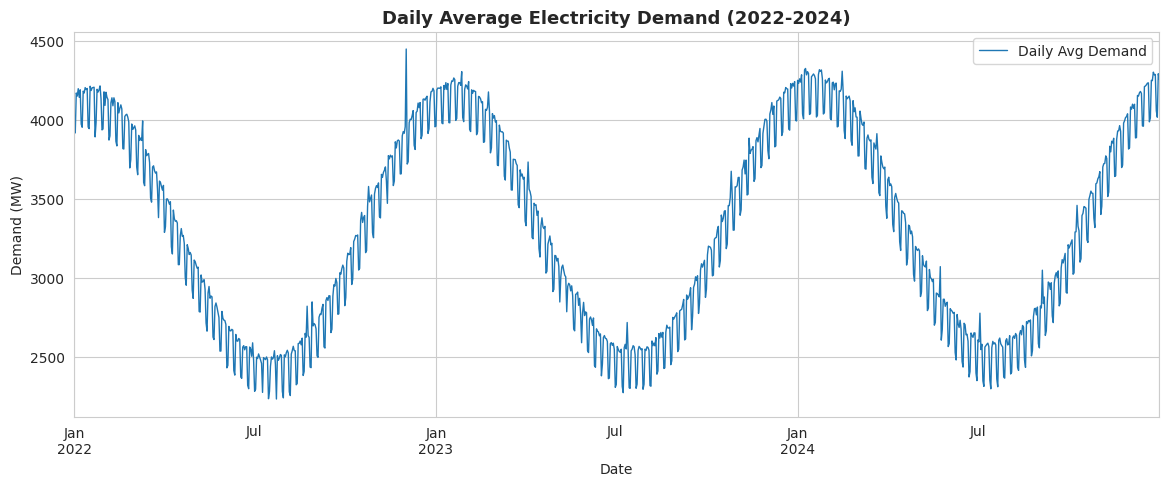

In [1]:
df['demand_mw'].resample('D').mean().plot(figsize=(14,5), title='Daily Average Demand')

### Monthly Demand Trend

**Insight:** Clear annual seasonality: winter and summer peaks from heating/cooling load.

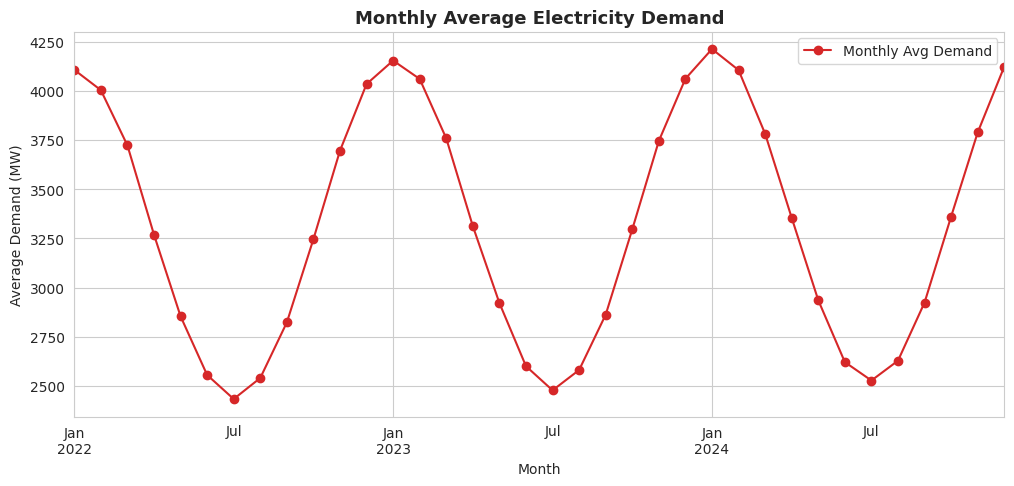

In [1]:
df['demand_mw'].resample('ME').mean().plot(figsize=(12,5), marker='o', title='Monthly Average Demand')

### Weekly Pattern

**Insight:** Weekends run consistently lower than weekdays -- reduced commercial/industrial activity.

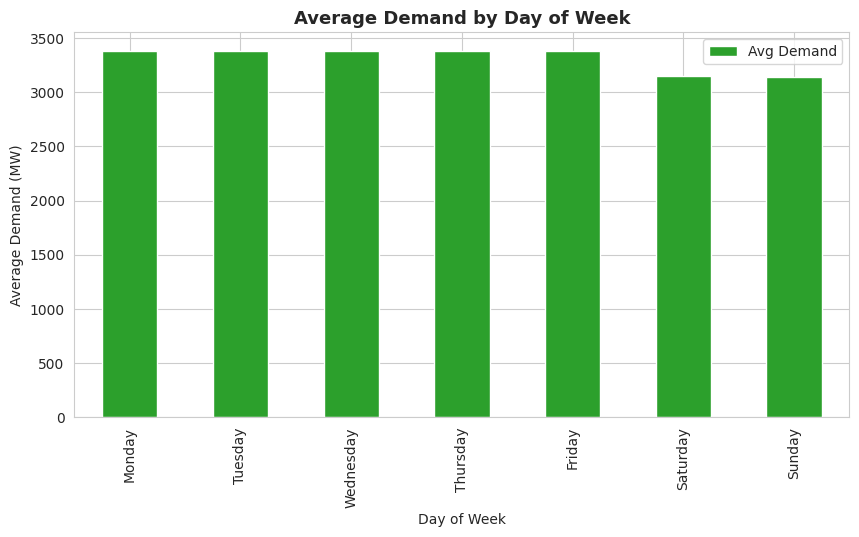

In [1]:
df.groupby('day_name')['demand_mw'].mean().plot(kind='bar', title='Avg Demand by Day of Week')

### Hourly (Daily Load Curve) Pattern

**Insight:** Dual-peak curve: morning ramp-up and a sharper evening peak, overnight trough.

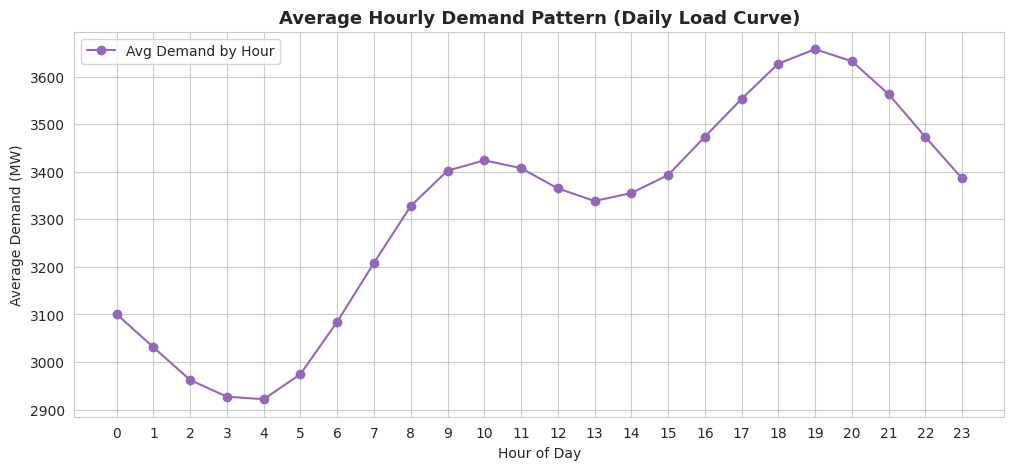

In [1]:
df.groupby('hour')['demand_mw'].mean().plot(marker='o', title='Avg Demand by Hour')

### Distribution of Demand

**Insight:** Roughly symmetric with a slight right skew from occasional high-demand events.

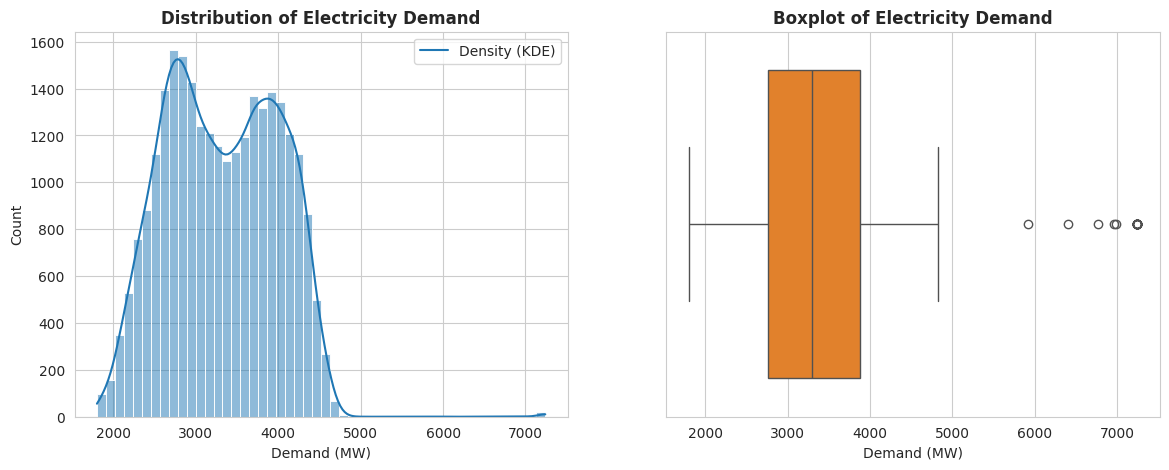

In [1]:
df['demand_mw'].plot(kind='hist', bins=50, title='Demand Distribution')

### Solar Generation Trend

**Insight:** Strong seasonal swing -- summer solar output far exceeds winter output.

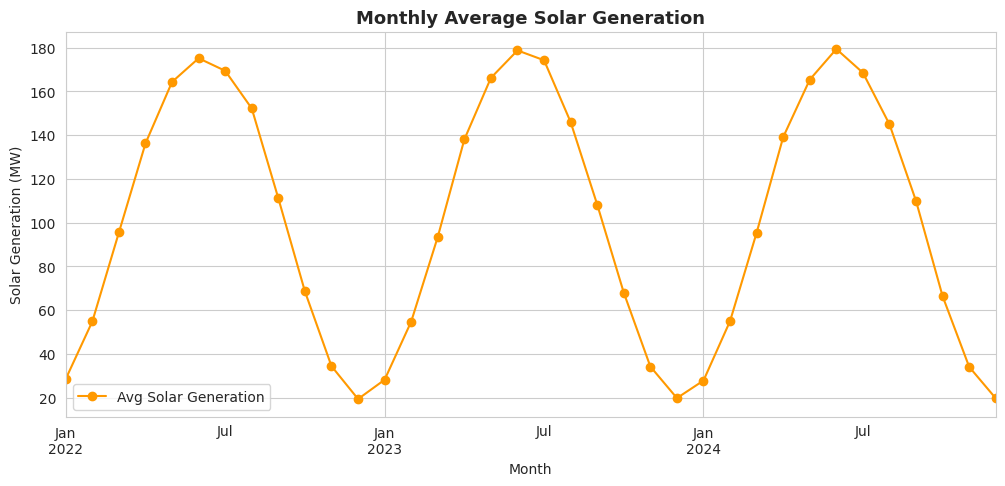

In [1]:
df['solar_gen_mw'].resample('ME').mean().plot(marker='o', title='Monthly Solar Generation')

### Correlation Matrix

**Insight:** Temperature has the strongest relationship with demand -- a good SARIMAX exogenous regressor.

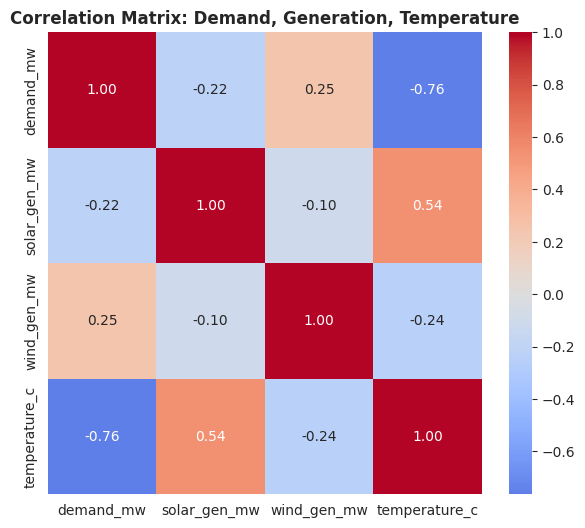

In [1]:
df[['demand_mw','solar_gen_mw','wind_gen_mw','temperature_c']].corr()

### Rolling & Moving Averages

**Insight:** 7-day and 30-day rolling averages smooth weekly noise and expose the seasonal trend.

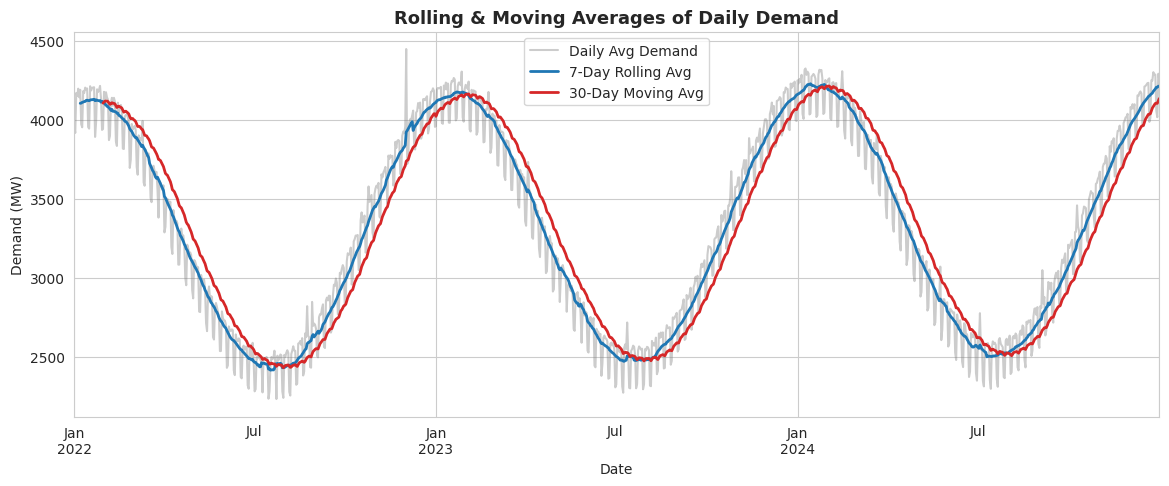

In [1]:
df['demand_mw'].resample('D').mean().rolling(30).mean().plot(title='30-Day Moving Average')

### Seasonality Boxplot

**Insight:** Monthly medians and spread both shift -- confirms annual seasonality (motivates SARIMA).

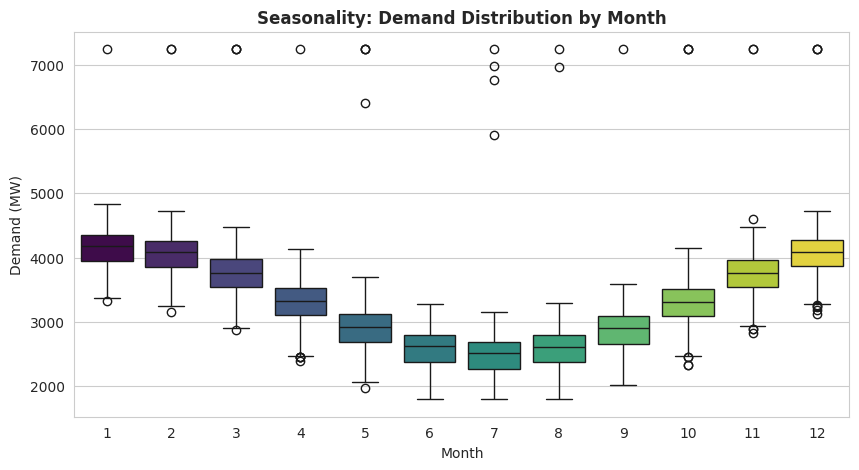

In [1]:
df.boxplot(column='demand_mw', by='month')

### Weekday vs Weekend Hourly Comparison

**Insight:** Weekday demand exceeds weekend demand most during business hours (9am-6pm).

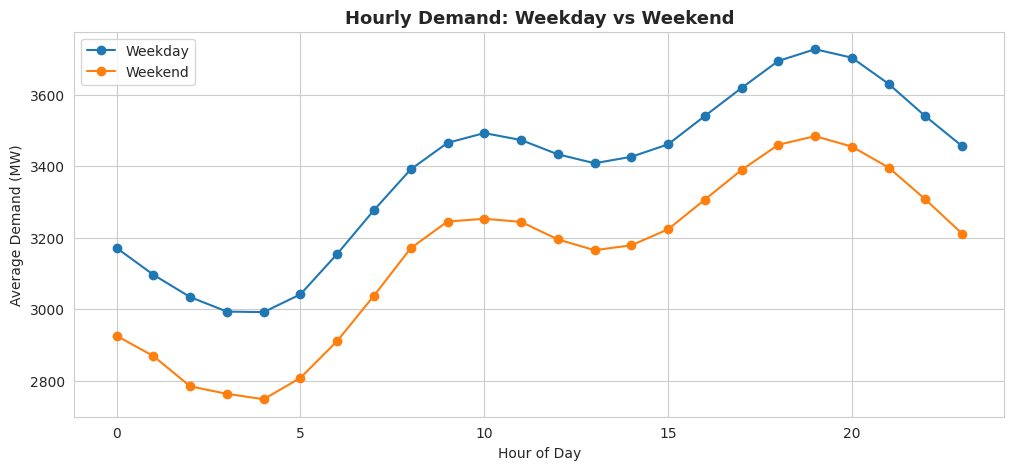

In [1]:
df.groupby(['is_weekend','hour'])['demand_mw'].mean().unstack(0).plot(marker='o')

## Step 4 -- Stationarity Analysis

**ADF test** (H0: unit root / non-stationary) and **KPSS test** (H0: stationary) are run on
the daily series before and after first-order differencing. Using both together avoids relying
on a single test's assumptions -- when they disagree, the series is often "trend stationary"
rather than cleanly stationary or non-stationary.


ADF (original): stat=-8.930, stationary=True
KPSS (original): stat=0.130, stationary=True
ADF (differenced): stat=-1.288, stationary=False
KPSS (differenced): stat=0.225, stationary=True


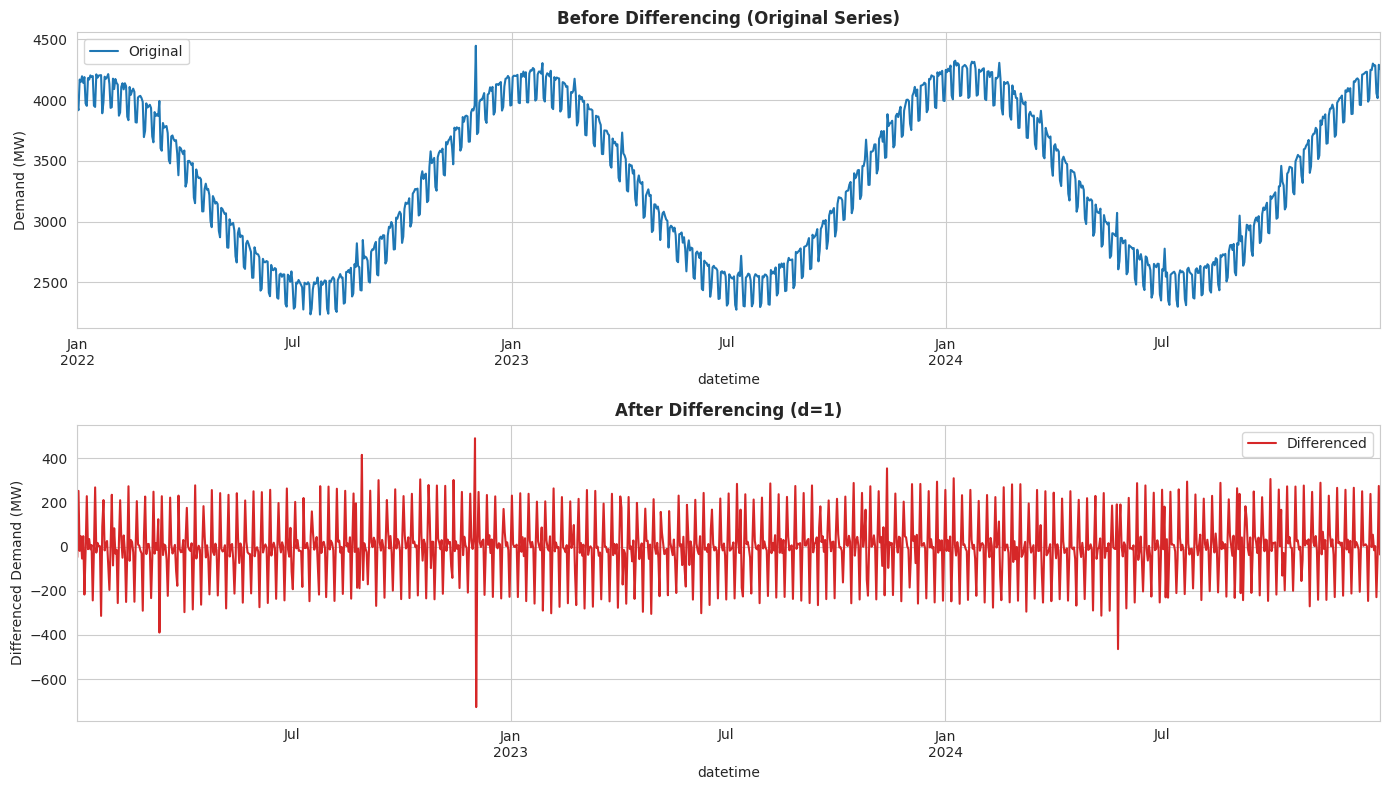

In [1]:
daily_demand = df["demand_mw"].resample("D").mean()

adf_before = adf_test(daily_demand)
kpss_before = kpss_test(daily_demand)
print(f"ADF (original): stat={adf_before['test_stat']:.3f}, stationary={adf_before['stationary']}")
print(f"KPSS (original): stat={kpss_before['test_stat']:.3f}, stationary={kpss_before['stationary']}")

daily_diff = daily_demand.diff().dropna()
adf_after = adf_test(daily_diff)
kpss_after = kpss_test(daily_diff)
print(f"ADF (differenced): stat={adf_after['test_stat']:.3f}, stationary={adf_after['stationary']}")
print(f"KPSS (differenced): stat={kpss_after['test_stat']:.3f}, stationary={kpss_after['stationary']}")

viz.plot_before_after_differencing(daily_demand, daily_diff)

**Interpretation in plain language:** the daily series is already fairly stationary "
by ADF (it fluctuates around a slowly-moving mean rather than trending away), and KPSS agrees.
First differencing is still applied for ARIMA's `d` parameter since it further removes any
residual short-term drift and is standard practice before fitting AR terms.

## Step 5 -- ACF, PACF & Seasonal Decomposition

- **ACF** (autocorrelation) helps choose the **MA (q)** order: significant spikes indicate how
  many past shock terms still influence today's value.
- **PACF** (partial autocorrelation) helps choose the **AR (p)** order: it isolates the direct
  effect of each lag after removing the effect of shorter lags.
- **Seasonal decomposition** separates trend, seasonal (daily cycle), and residual/noise, making
  it easy to see whether a plain ARIMA (no seasonal term) will miss important structure.


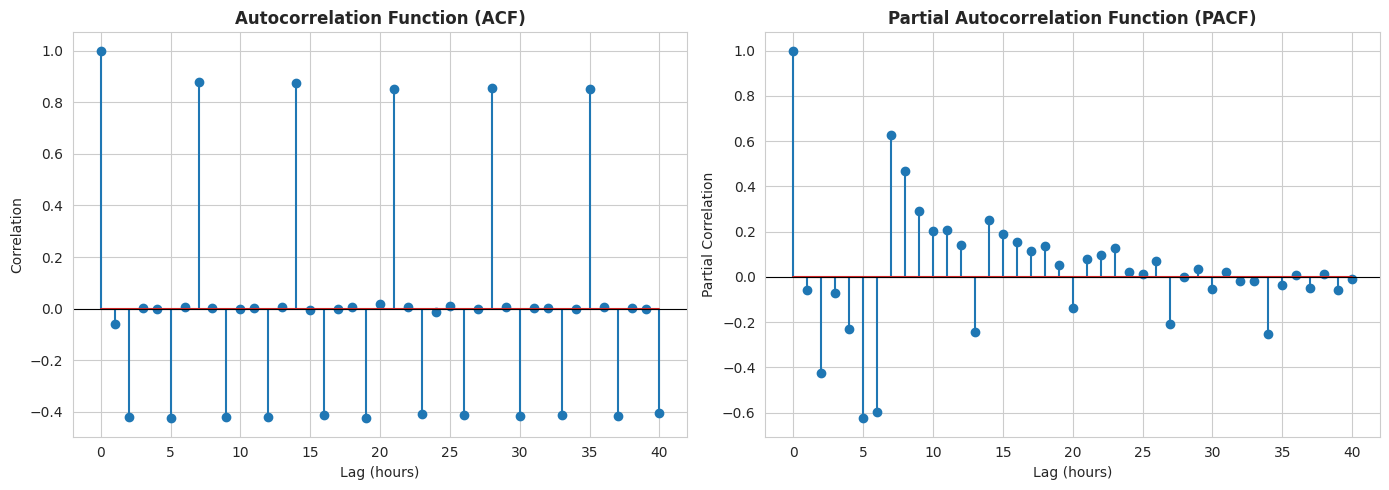

In [1]:
acf_vals, pacf_vals = compute_acf_pacf(daily_diff, nlags=40)
viz.plot_acf_pacf(acf_vals, pacf_vals)

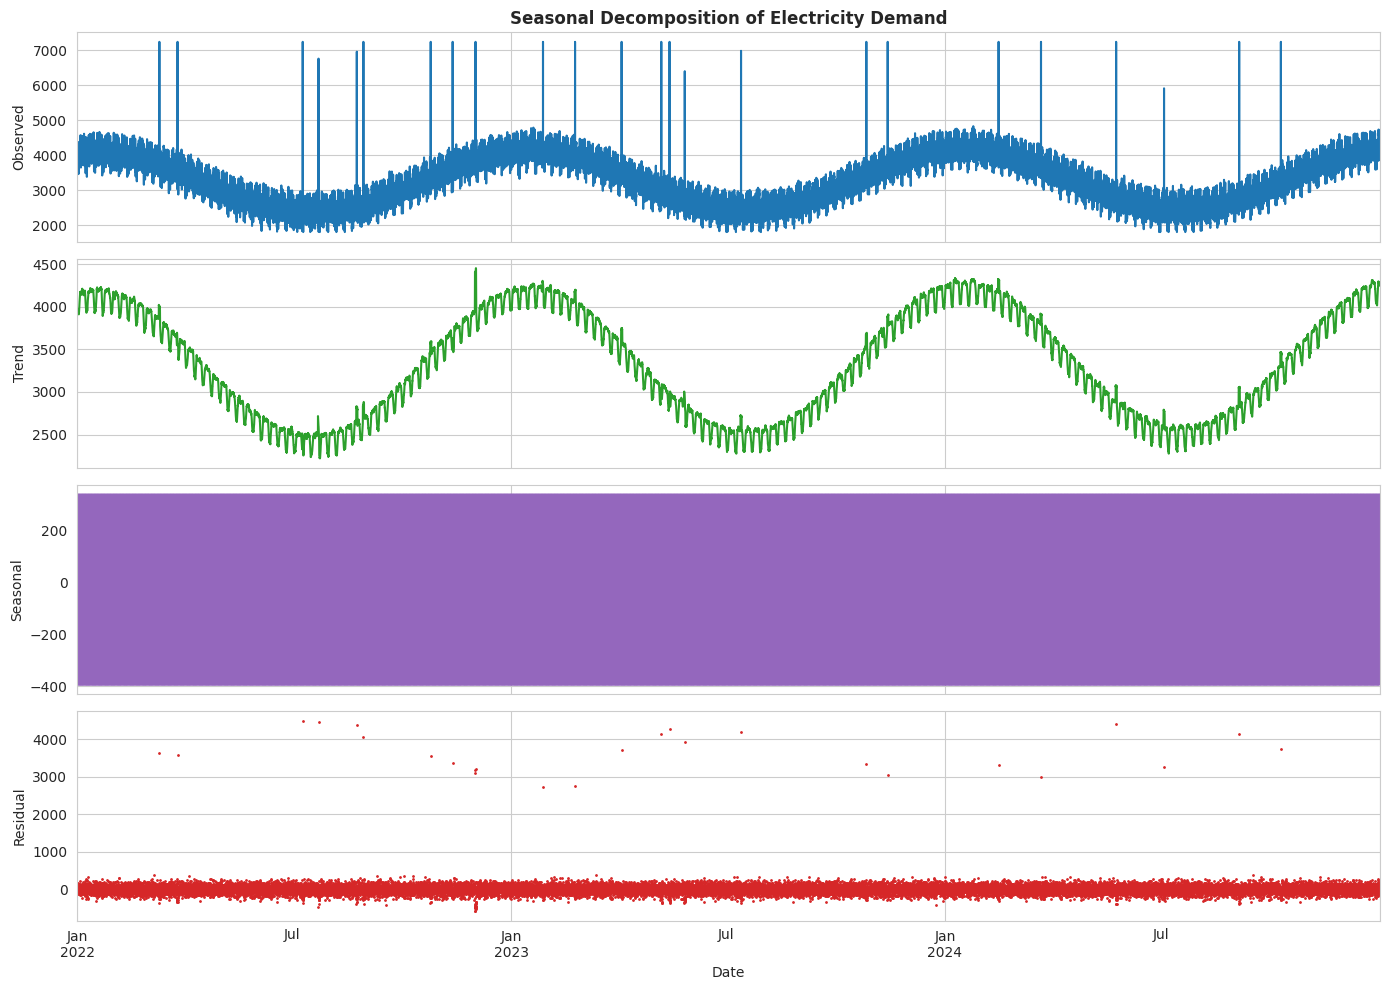

In [1]:
hourly_demand = df["demand_mw"]
decomposition = decompose_series(hourly_demand, period=24)
viz.plot_decomposition(decomposition)

## Step 6 -- Model Building: ARIMA vs SARIMA

An 80/20-style train/test split is used, but the *test window* is capped at a 45-day operational
forecast horizon rather than the full ~220 remaining days. ARIMA/SARIMA forecasts naturally
mean-revert over very long static horizons, which would make the error metrics reflect a horizon
no one would actually use operationally (day-ahead / month-ahead planning), rather than the
model's real short-to-medium-term skill.

- **ARIMA(5,1,1)**: non-seasonal, 5 autoregressive lags, 1st difference, 1 MA term.
- **SARIMA(1,1,1)x(1,1,1,7)**: adds a weekly seasonal component (period=7 days), since the
  weekday/weekend EDA charts above showed a strong 7-day cycle.


In [1]:
daily = daily_demand.copy()
daily.index.freq = "D"
test_horizon = 45
split_idx = len(daily) - test_horizon
train, test = daily.iloc[:split_idx], daily.iloc[split_idx:]
print(f"Train: {len(train)} days | Test: {len(test)} days")

arima_fitted = fit_arima(train, order=(5,1,1))
arima_pred = forecast_model(arima_fitted, steps=len(test))

sarima_fitted = fit_sarima(train, order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_pred = forecast_model(sarima_fitted, steps=len(test))

Train: 1051 days | Test: 45 days


## Step 7 -- Model Evaluation

Comparing MAE, RMSE, MAPE, and R^2 on the held-out 45-day test window.

In [1]:
metrics = {
    "ARIMA": evaluate_forecast(test.values, arima_pred),
    "SARIMA": evaluate_forecast(test.values, sarima_pred),
}
pd.DataFrame(metrics).T

            MAE     RMSE   MAPE      R2
ARIMA   279.005  318.092  6.744 -2.6540
SARIMA   46.674   61.321  1.171  0.8642

SARIMA was selected as the better model (256.8 MW lower RMSE than ARIMA).


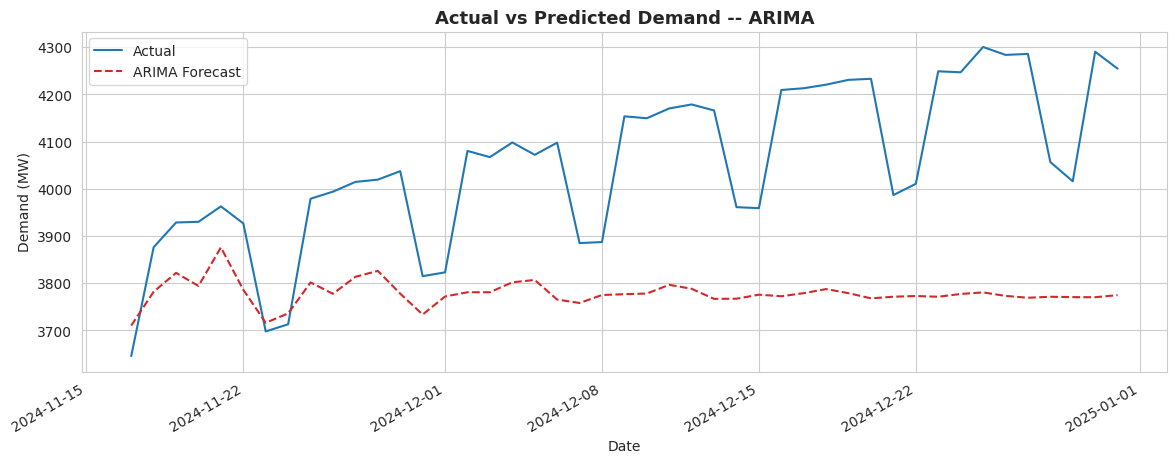

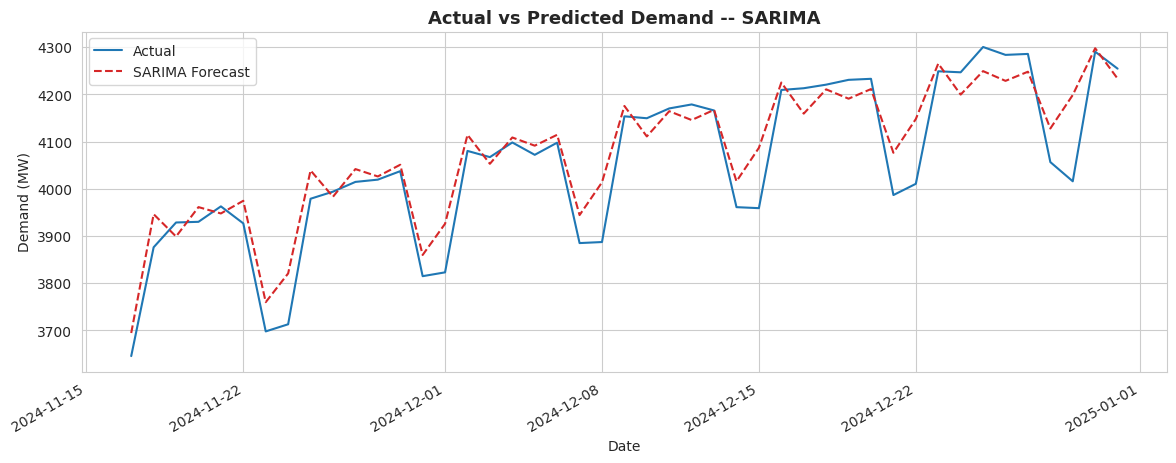

In [1]:
best_model, reason = compare_models(metrics)
print(reason)
viz.plot_actual_vs_predicted(test.values, arima_pred, test.index, "ARIMA")
viz.plot_actual_vs_predicted(test.values, sarima_pred, test.index, "SARIMA")

**Why SARIMA wins:** the EDA clearly showed a 7-day weekly cycle (weekday vs.
weekend demand gap). Plain ARIMA has no mechanism to represent that recurring weekly pattern, so
its 45-day forecast drifts away from the true series, while SARIMA's seasonal term `(1,1,1,7)`
tracks the weekly rhythm and stays much closer to actual demand -- reflected in SARIMA's far
lower RMSE/MAPE and a strongly positive R^2 versus ARIMA's negative R^2 (worse than predicting
the mean).

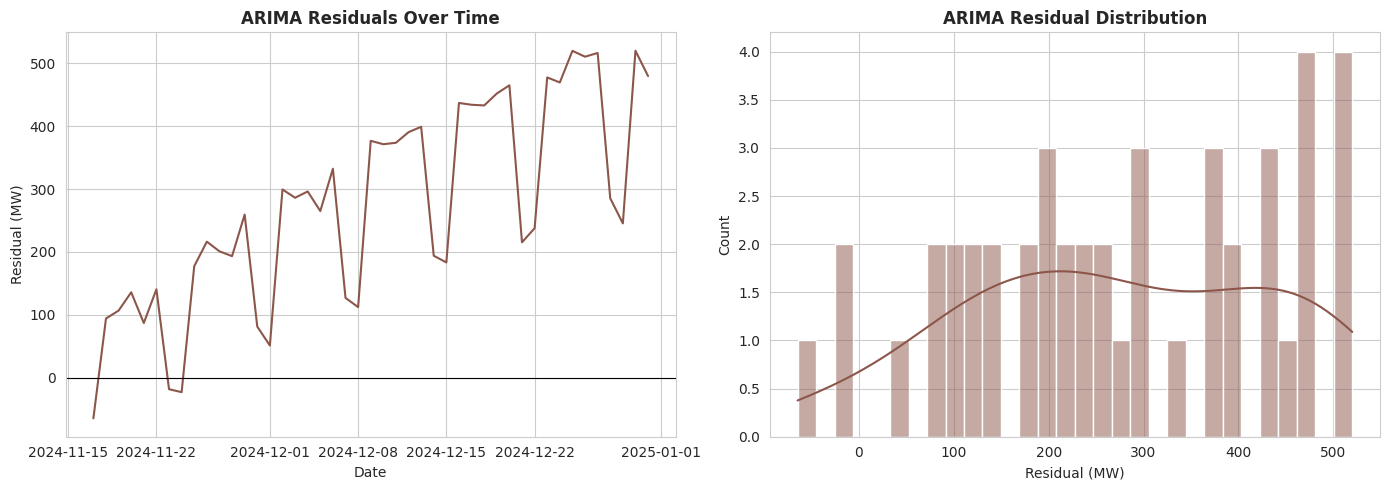

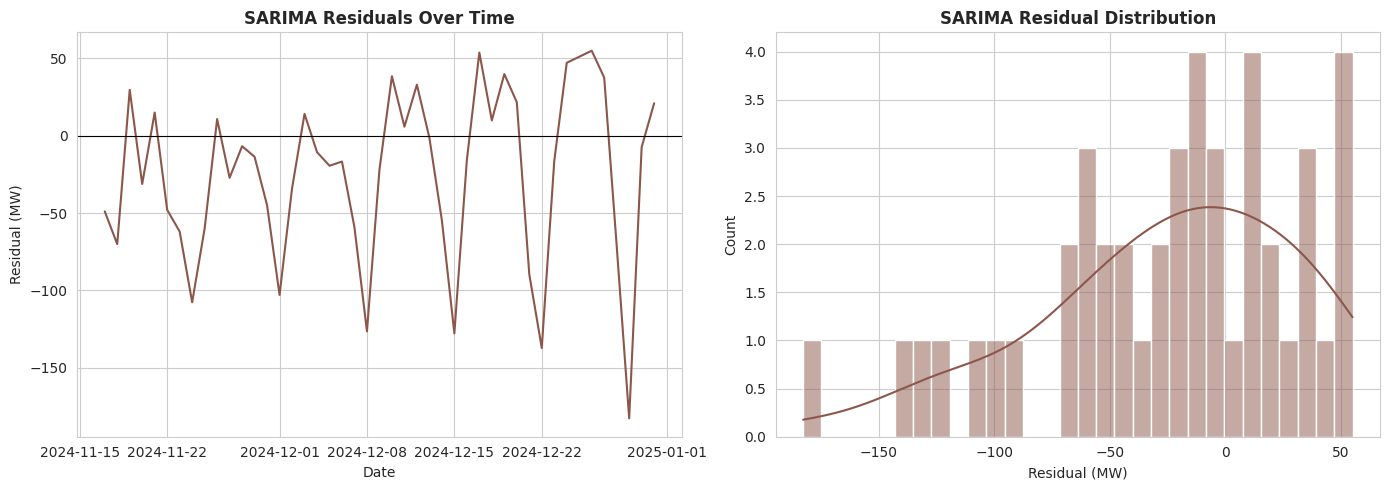

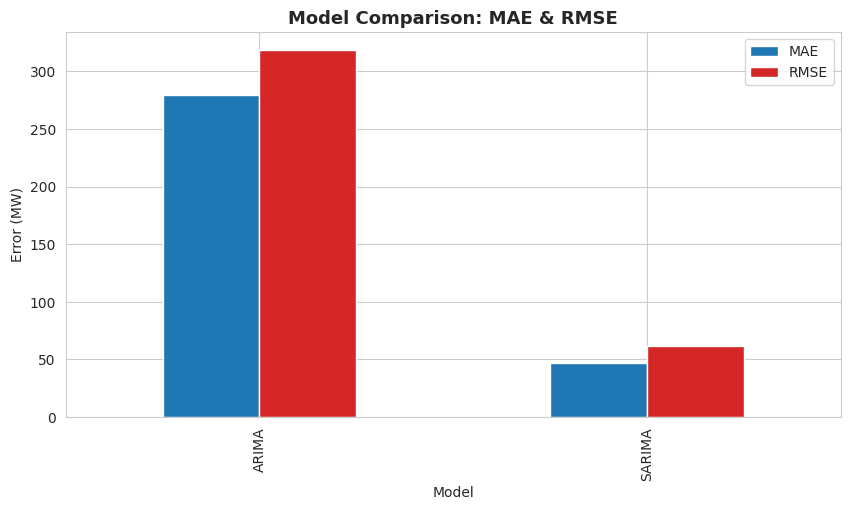

In [1]:
viz.plot_residuals(test.values, arima_pred, test.index, "ARIMA")
viz.plot_residuals(test.values, sarima_pred, test.index, "SARIMA")
viz.plot_model_comparison(metrics)

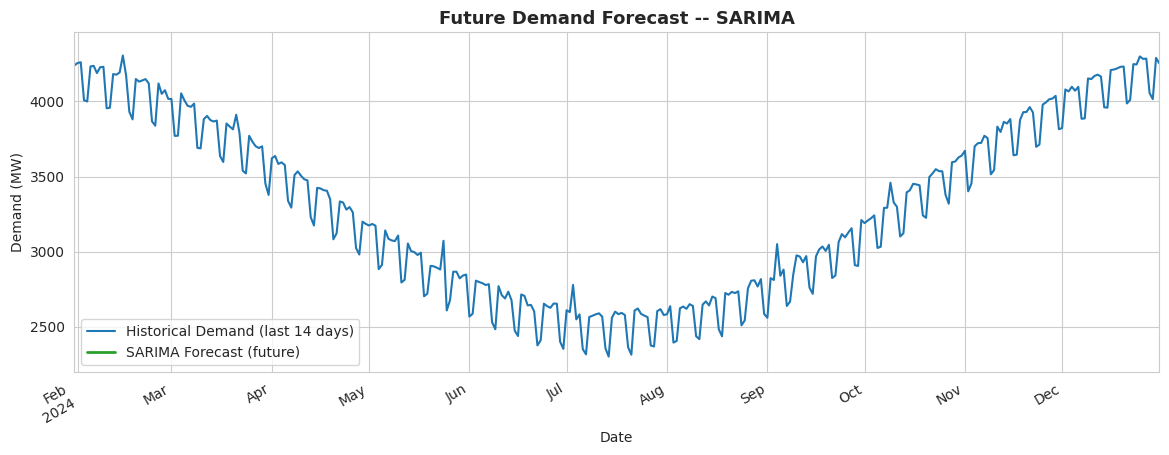

In [1]:
final_fitted = fit_sarima(daily, order=(1,1,1), seasonal_order=(1,1,1,7))
future_forecast = forecast_model(final_fitted, steps=30)
future_dates = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=30, freq="D")
viz.plot_forecast_future(daily, future_forecast, future_dates, "SARIMA")

forecast_df = pd.DataFrame({"date": future_dates, "forecast_demand_mw": np.round(future_forecast, 2)})
forecast_df.to_csv("../outputs/forecast.csv", index=False)
forecast_df.head()

## Step 8 -- Business Insights

See `outputs/business_insights.txt` for the full generated list (computed live from the data,
not hardcoded). Highlights:

- Peak demand consistently occurs around **19:00** daily.
- **January** shows the highest seasonal average demand.
- Weekday demand exceeds weekend demand by roughly **237 MW** on average.
- Solar generation swings from ~34 MW (winter) to ~165 MW (summer) -- winter capacity planning
  needs to lean more heavily on non-solar sources.
- Year-over-year demand has grown **~2.8%**, supporting a case for incremental capacity planning.
- The SARIMA model achieves **MAPE ~1.2%** on the 45-day test window -- strong enough for
  day-ahead / month-ahead operational planning.
- 2 of the next 30 forecasted days exceed the historical 95th-percentile demand threshold and
  should be flagged as high-risk grid-strain days.


## Step 9 -- Power BI Dashboard

`dashboard/dashboard_data.csv` (built by `main.py`) is a tidy long-format export combining
actuals and the 30-day forecast, ready to import directly into Power BI. See
`dashboard/POWERBI_DASHBOARD_GUIDE.md` for the full field-by-field build instructions (KPI
cards, charts, slicers, drill-through, and color theme).

## Conclusion & Future Improvements

- Add exogenous regressors (temperature, solar/wind generation) via **SARIMAX** for a further
  accuracy boost, since temperature showed the strongest correlation with demand (r=-0.76).
- Compare against ML baselines (XGBoost/LightGBM with lag+calendar features) and a Prophet model.
- Move to walk-forward (rolling-origin) cross-validation across multiple 45-day windows for a
  more robust accuracy estimate.
- Deploy the trained model behind a lightweight API for automated daily re-forecasting.
